In [ ]:
from google.colab import files

uploaded = files.upload()

Saving 01 Retail Inventory.xlsx to 01 Retail Inventory.xlsx


In [ ]:
import pandas as pd

df = pd.read_excel(list(uploaded.keys())[0])

df.head()

,Product ID,Product Name,Category,Supplier Name,Unit Cost,Retail Price,Opening Stock,Units Sold,Closing Stock,Reorder Point,Stock Status
0,PRD-1001,Wine Glasses,Home & Kitchen,Heritage Brands,23.78,38.89,135,118,17,30,Low Stock
1,PRD-1002,Eye Mask,Beauty,Coastal Trading,15.67,24.53,86,10,76,9,In Stock
2,PRD-1003,Resistance Band,Sports & Outdoors,National Supply Group,5.59,11.88,319,195,124,47,In Stock
3,PRD-1004,Action Figure,Toys & Games,Pacific Wholesale,9.72,18.01,173,140,33,39,Low Stock
4,PRD-1005,Serving Tray,Home & Kitchen,Coastal Trading,8.22,13.90,32,8,24,7,In Stock


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [ ]:
print(df.shape)

(1000, 11)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product ID     1000 non-null   object 
 1   Product Name   1000 non-null   object 
 2   Category       1000 non-null   object 
 3   Supplier Name  1000 non-null   object 
 4   Unit Cost      1000 non-null   float64
 5   Retail Price   1000 non-null   float64
 6   Opening Stock  1000 non-null   int64  
 7   Units Sold     1000 non-null   int64  
 8   Closing Stock  1000 non-null   int64  
 9   Reorder Point  1000 non-null   int64  
 10  Stock Status   1000 non-null   object 
dtypes: float64(2), int64(4), object(5)
memory usage: 86.1+ KB


In [ ]:
df.describe()

,Unit Cost,Retail Price,Opening Stock,Units Sold,Closing Stock,Reorder Point
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,16.061210,27.976780,262.451000,137.040000,125.411000,44.98300
std,14.172094,24.915064,140.104457,103.623232,99.023521,27.54468
min,0.520000,1.070000,20.000000,3.000000,4.000000,2.00000
25%,7.035000,11.962500,141.750000,53.000000,44.000000,22.00000
50%,12.430000,21.760000,261.000000,108.500000,96.000000,41.00000
75%,20.775000,35.307500,388.000000,204.000000,190.000000,64.25000
max,78.790000,157.400000,499.000000,463.000000,432.000000,119.00000


In [ ]:
df.isnull().sum()

,0
Product ID,0
Product Name,0
Category,0
Supplier Name,0
Unit Cost,0
Retail Price,0
Opening Stock,0
Units Sold,0
Closing Stock,0
Reorder Point,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
df = df.fillna("Unknown")

In [ ]:
df[['Opening Stock','Units Sold','Reorder Point']].describe()
df = df[df['Opening Stock'] >= 0]
df = df[df['Units Sold'] >= 0]
df = df[df['Reorder Point'] >= 0]

In [ ]:
category_count = df['Category'].value_counts()

print(category_count)

Category
Beauty               134
Sports & Outdoors    132
Electronics          126
Office Supplies      126
Home & Kitchen       124
Toys & Games         123
Grocery              119
Clothing             116
Name: count, dtype: int64


In [ ]:
category_sales = df.groupby('Category')['Units Sold'].sum()

print(category_sales.sort_values(ascending=False))

Category
Toys & Games         19704
Home & Kitchen       18387
Beauty               18137
Electronics          17621
Office Supplies      17112
Sports & Outdoors    16979
Grocery              15364
Clothing             13736
Name: Units Sold, dtype: int64


In [ ]:
top_products = df.nlargest(10,'Units Sold')

top_products[['Product Name','Units Sold']]

,Product Name,Units Sold
721,Water Bottle,463
476,Canned Soup,456
791,Coffee Mug Set,435
673,LED Desk Lamp,432
810,Coloring Set,428
243,Notebook A5,423
550,Whistle,422
970,Baseball Cap,422
931,Rice Crackers,417
469,Building Blocks,416


In [ ]:
low_stock = df.nsmallest(10,'Opening Stock')

low_stock[['Product Name','Opening Stock']]

,Product Name,Opening Stock
389,Hair Brush,20
786,Canvas Belt,20
6,Dish Soap,21
19,Dry Shampoo,21
420,Coffee Mug Set,21
698,Whistle,21
614,Puzzle 500pc,22
838,Resistance Band,22
93,Beanie Hat,25
574,Golf Tees,25


In [ ]:
reorder_products = df[
    df['Opening Stock'] <= df['Reorder Point']
]

reorder_products

,Product ID,Product Name,Category,Supplier Name,Unit Cost,Retail Price,Opening Stock,Units Sold,Closing Stock,Reorder Point,Stock Status


In [ ]:
supplier_products = df.groupby('Supplier Name').size()
print(supplier_products)

Supplier Name
AllGoods Supply Co        72
Coastal Trading          103
Global Source Direct     103
Heritage Brands          109
Metro Distributors        89
National Supply Group    116
Pacific Wholesale         98
Premier Merchandise      119
Summit Wholesale Inc      92
United Imports            99
dtype: int64


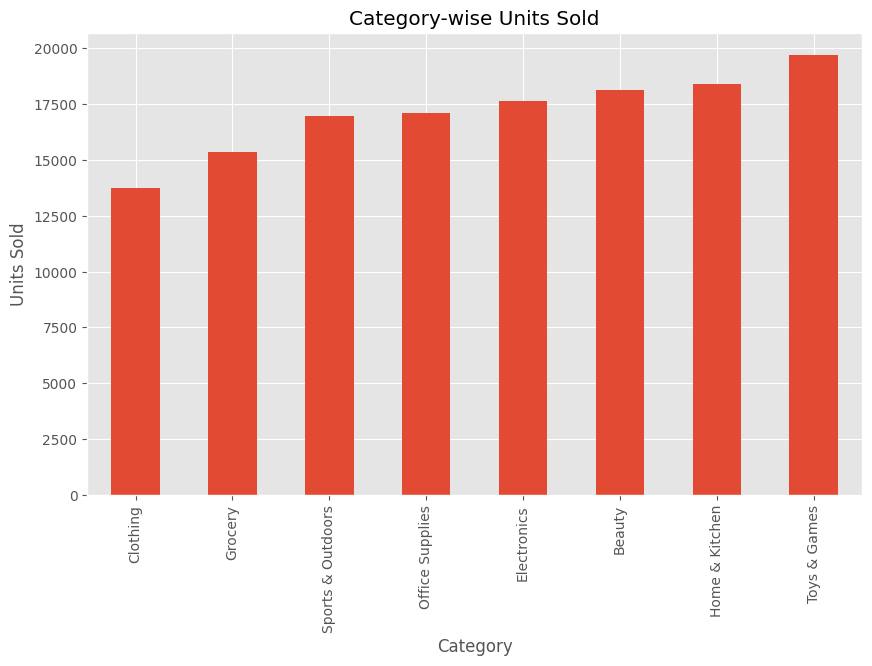

In [ ]:
plt.figure(figsize=(10,6))

category_sales.sort_values().plot(kind='bar')

plt.title("Category-wise Units Sold")
plt.xlabel("Category")
plt.ylabel("Units Sold")

plt.show()

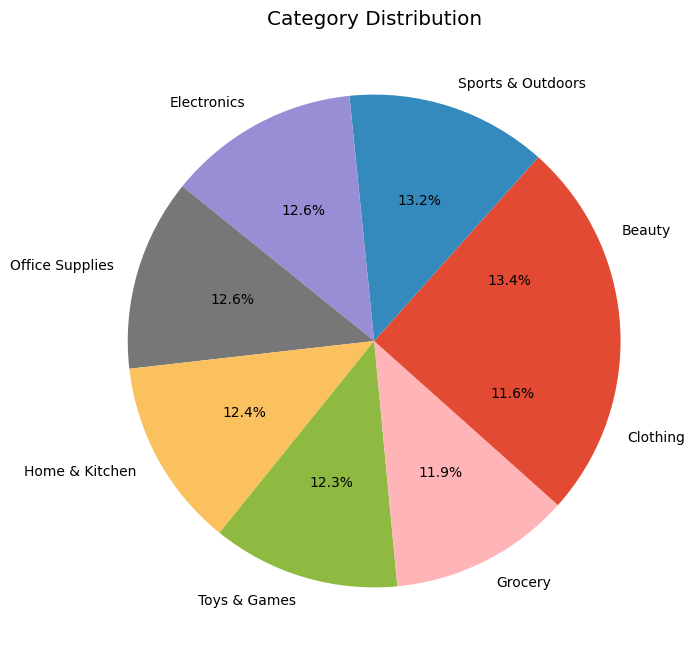

In [ ]:
plt.figure(figsize=(8,8))

category_count.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title("Category Distribution")

plt.show()

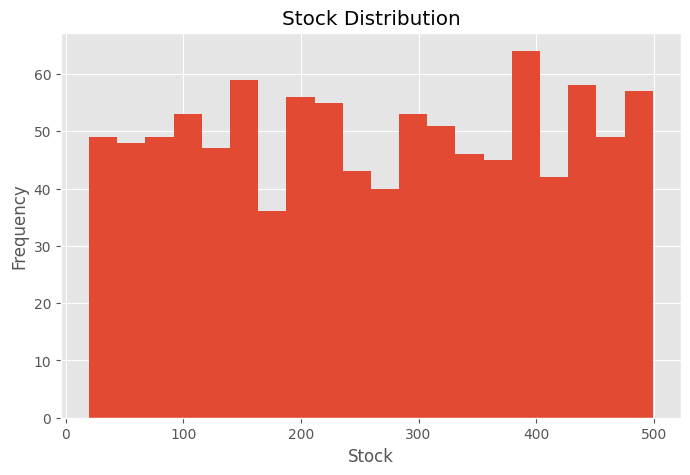

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df['Opening Stock'], bins=20)

plt.title("Stock Distribution")
plt.xlabel("Stock")
plt.ylabel("Frequency")

plt.show()

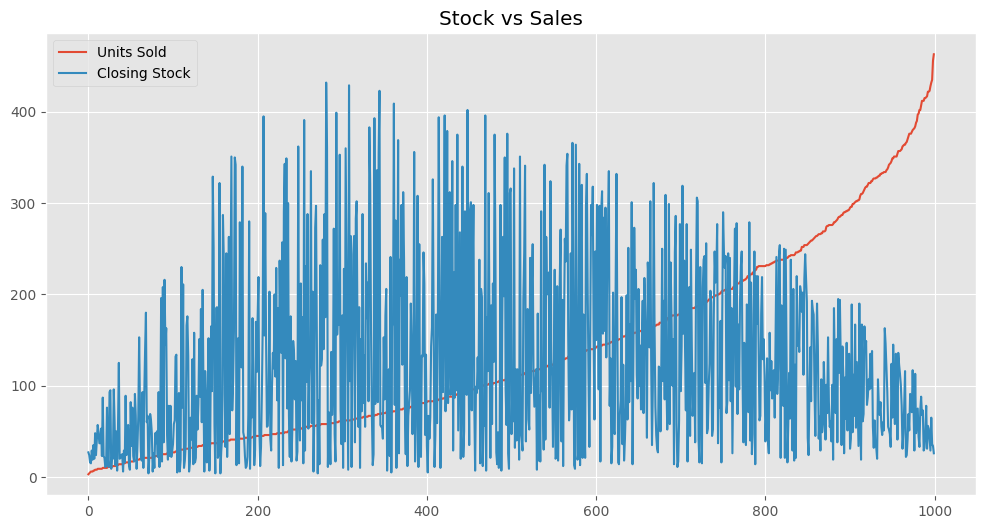

In [ ]:
df_sorted = df.sort_values('Units Sold')

plt.figure(figsize=(12,6))

plt.plot(df_sorted['Units Sold'].values,
         label='Units Sold')

plt.plot(df_sorted['Closing Stock'].values,
         label='Closing Stock')

plt.legend()

plt.title("Stock vs Sales")

plt.show()

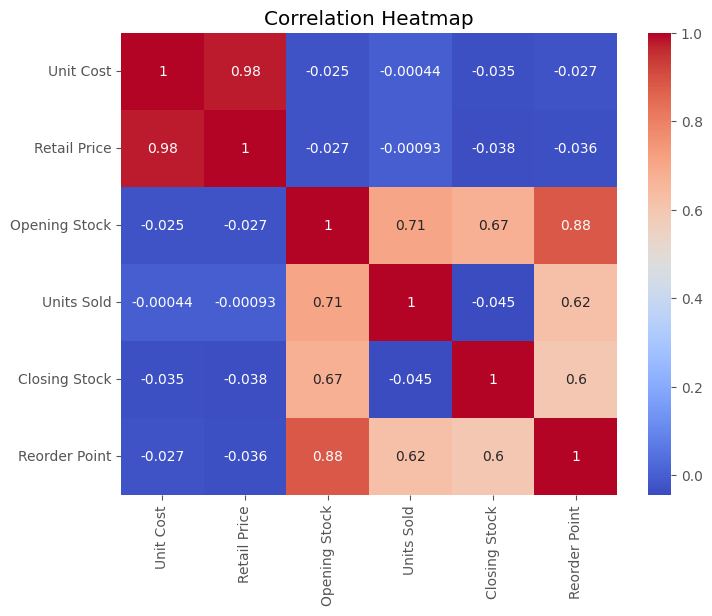

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()